# Классификация текстов с использованием Наивного Байесовского Классификатора

## Задание 1 (1 балл)

Откройте данные. Узнайте, сколько в них спам- и не спам-писем. Визуализируйте полученные соотношение подходящим образом.

In [48]:
import numpy as np
import pandas as pd

In [96]:
sms_data = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/spam_or_not_spam.csv', sep=',')
sms_data


,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0
...,...,...
2995,abc s good morning america ranks it the NUMBE...,1
2996,hyperlink hyperlink hyperlink let mortgage le...,1
2997,thank you for shopping with us gifts for all ...,1
2998,the famous ebay marketing e course learn to s...,1


In [73]:
s = sms_data.groupby('label').count()
s

,email
label,
0,2500
1,499


## Задание 2 (2 балла)

Вам необходимо предобработать ваши данные и перевести их в векторный вид. Подгрузим необходимый модуль:

In [75]:
from sklearn.feature_extraction.text import CountVectorizer

Замените в данных все пустые строки и строки, состоящие из пробелов, на пропуски (NaN). После этого удалите из данных все строки, в которых наблюдаются пропущенные значения.

In [95]:
data_cleaned = sms_data.replace(r'^\s*$', np.nan, regex=True)
data_final = data_cleaned.dropna()
data_final

,email,label
0,date wed NUMBER aug NUMBER NUMBER NUMBER NUMB...,0
1,martin a posted tassos papadopoulos the greek ...,0
2,man threatens explosion in moscow thursday aug...,0
3,klez the virus that won t die already the most...,0
4,in adding cream to spaghetti carbonara which ...,0
...,...,...
2995,abc s good morning america ranks it the NUMBE...,1
2996,hyperlink hyperlink hyperlink let mortgage le...,1
2997,thank you for shopping with us gifts for all ...,1
2998,the famous ebay marketing e course learn to s...,1


In [112]:
data_final['email'] = data_final['email'].str.replace('\W+', ' ', regex=True)

data_final['email'] = data_final['email'].str.replace('\s+', ' ', regex=True).str.strip()
data_final['email'] = data_final['email'].str.lower()
data_final['email'] = data_final['email'].str.split()

data_final['email'].head()

<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Admin\AppData\Local\Temp\ipykernel_11776\1937538695.py:1: SyntaxWarning: invalid escape sequence '\W'
  data_final['email'] = data_final['email'].str.replace('\W+', ' ', regex=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11776\1937538695.py:3: SyntaxWarning: invalid escape sequence '\s'
  data_final['email'] = data_final['email'].str.replace('\s+', ' ', regex=True).str.strip()
C:\Users\Admin\AppData\Local\Temp\ipykernel_11776\1937538695.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final['email'] = data_final['email'].str.rep

0    [date, wed, number, aug, number, number, numbe...
1    [martin, a, posted, tassos, papadopoulos, the,...
2    [man, threatens, explosion, in, moscow, thursd...
3    [klez, the, virus, that, won, t, die, already,...
4    [in, adding, cream, to, spaghetti, carbonara, ...
Name: email, dtype: object

Переводим данные в векторный вид:

In [117]:
from sklearn.feature_extraction.text import CountVectorizer
# Преобразуем списки в строки
data_final['email_text'] = data_final['email'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

# Теперь можно использовать CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data_final['email_text'])

print(f"Размер матрицы: {X.shape}")
print(f"Количество уникальных слов: {len(vectorizer.get_feature_names_out())}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_11776\2742344906.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final['email_text'] = data_final['email'].apply(


Размер матрицы: (2997, 34116)
Количество уникальных слов: 34116


In [119]:
X.shape

(2997, 34116)

Определите, сколько теперь признаков в нашем наборе данных:

In [120]:
data_final.groupby('label').count()


,email,email_text
label,,
0,2500,2500
1,497,497


In [121]:
data_without_label = data_final.drop('label', axis=1)

## Задание 3 (2 балла)

Определите целевую переменную и признаки:

In [122]:

y = data_final["label"]

Разделите выборку на обучающую и тестовую, используя стратифицированное разбиение (параметр `stratify` установите в значение вектора ответов y) размер тестовой выборки (`test_size`) возьмите как 0.25, параметр `random_state` определите со значением 42:

In [131]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB

In [124]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, test_size=0.25, stratify=y, random_state=42)

Рассчитайте среднее значение целевой переменной по тестовой выборке:

In [125]:
y_test.mean()

np.float64(0.16533333333333333)

## Задание 4 (3 балла)

Определите и обучите подходящий алгоритм с параметром alpha = 0.01

МНОГОЧЛЕННЫЙ НАИВНЫЙ БАЙЕС С alpha=0.01

Accuracy: 0.9867

Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.98      1.00      0.99       626
    Spam (1)       1.00      0.92      0.96       124

    accuracy                           0.99       750
   macro avg       0.99      0.96      0.98       750
weighted avg       0.99      0.99      0.99       750


СРАВНЕНИЕ alpha=0.01 vs alpha=1.0 (по умолчанию)

Accuracy:
  alpha=0.01: 0.9867
  alpha=1.0:  0.9893
  Разница:    -0.0027

АНАЛИЗ ВЛИЯНИЯ ПАРАМЕТРА alpha
  alpha=0.001: 0.9853
  alpha=0.010: 0.9867  ← ваш выбор
  alpha=0.100: 0.9933
  alpha=0.500: 0.9933
  alpha=1.000: 0.9893
  alpha=2.000: 0.9867
  alpha=5.000: 0.9547


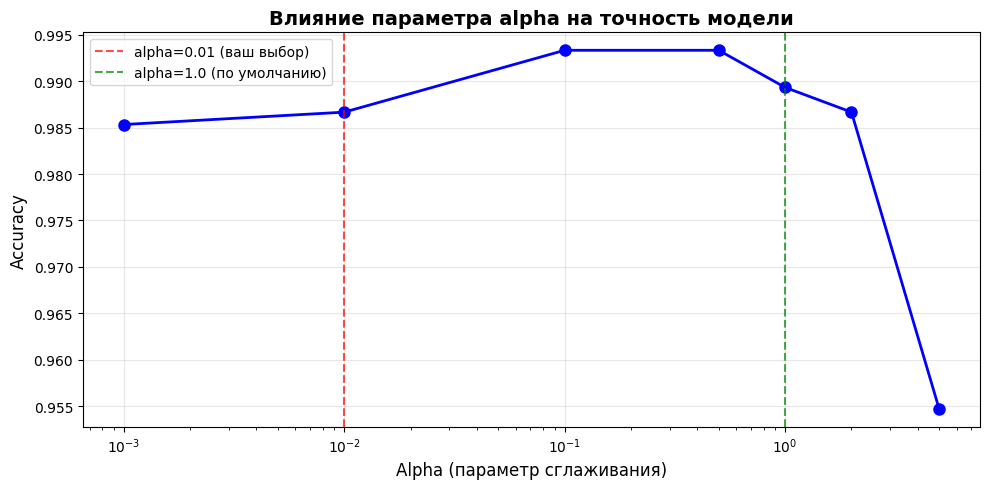


ДЕТАЛЬНЫЙ АНАЛИЗ ПРЕДСКАЗАНИЙ (alpha=0.01)

Confusion Matrix:
                 Predicted
                 Ham    Spam
Actual Ham     [  626      0]
       Spam    [   10    114]

Метрики по классам:
Для Ham (класс 0):
  Precision: 0.9843  Recall: 1.0000

Для Spam (класс 1):
  Precision: 1.0000  Recall: 0.9194

ВЕРОЯТНОСТИ ПРЕДСКАЗАНИЙ

Пример вероятностей для первых 5 тестовых примеров:
Пример 0:
  Фактический класс: 0
  Предсказанный класс: 0
  P(Ham)=1.0000, P(Spam)=0.0000

Пример 1:
  Фактический класс: 0
  Предсказанный класс: 0
  P(Ham)=1.0000, P(Spam)=0.0000

Пример 2:
  Фактический класс: 0
  Предсказанный класс: 0
  P(Ham)=1.0000, P(Spam)=0.0000

Пример 3:
  Фактический класс: 0
  Предсказанный класс: 0
  P(Ham)=1.0000, P(Spam)=0.0000

Пример 4:
  Фактический класс: 0
  Предсказанный класс: 0
  P(Ham)=1.0000, P(Spam)=0.0000


АНАЛИЗ УВЕРЕННОСТИ ПРЕДСКАЗАНИЙ

Статистика уверенности модели:
  Средняя уверенность: 0.9989
  Минимальная уверенность: 0.7466
  Максимальная уверенност

In [133]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# 1. Модель с alpha=0.01
clf_alpha = MultinomialNB(alpha=0.01)
clf_alpha.fit(X_train, y_train)

# 2. Предсказания
y_test_pred_alpha = clf_alpha.predict(X_test)

# 3. Оценка модели
print("="*60)
print("МНОГОЧЛЕННЫЙ НАИВНЫЙ БАЙЕС С alpha=0.01")
print("="*60)

print(f"\nAccuracy: {accuracy_score(y_test, y_test_pred_alpha):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_alpha, 
                           target_names=['Ham (0)', 'Spam (1)']))

# 4. Сравнение с моделью без указания alpha (по умолчанию alpha=1.0)
print("\n" + "="*60)
print("СРАВНЕНИЕ alpha=0.01 vs alpha=1.0 (по умолчанию)")
print("="*60)

# Модель с alpha=1.0 (по умолчанию)
clf_default = MultinomialNB()  # alpha=1.0 по умолчанию
clf_default.fit(X_train, y_train)
y_test_pred_default = clf_default.predict(X_test)

accuracy_alpha = accuracy_score(y_test, y_test_pred_alpha)
accuracy_default = accuracy_score(y_test, y_test_pred_default)

print(f"\nAccuracy:")
print(f"  alpha=0.01: {accuracy_alpha:.4f}")
print(f"  alpha=1.0:  {accuracy_default:.4f}")
print(f"  Разница:    {accuracy_alpha - accuracy_default:+.4f}")

# 5. Анализ влияния alpha
print("\n" + "="*60)
print("АНАЛИЗ ВЛИЯНИЯ ПАРАМЕТРА alpha")
print("="*60)

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0]
results = []

for a in alphas:
    clf = MultinomialNB(alpha=a)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append(acc)
    
    if a == 0.01:
        print(f"  alpha={a:.3f}: {acc:.4f}  ← ваш выбор")
    else:
        print(f"  alpha={a:.3f}: {acc:.4f}")

# Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(alphas, results, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=0.01, color='red', linestyle='--', alpha=0.7, label='alpha=0.01 (ваш выбор)')
plt.axvline(x=1.0, color='green', linestyle='--', alpha=0.7, label='alpha=1.0 (по умолчанию)')
plt.xlabel('Alpha (параметр сглаживания)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Влияние параметра alpha на точность модели', fontsize=14, fontweight='bold')
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Детальный анализ предсказаний
print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ПРЕДСКАЗАНИЙ (alpha=0.01)")
print("="*60)

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred_alpha)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Ham    Spam")
print(f"Actual Ham     [{tn:5d}  {fp:5d}]")
print(f"       Spam    [{fn:5d}  {tp:5d}]")

print(f"\nМетрики по классам:")
print(f"Для Ham (класс 0):")
print(f"  Precision: {tn/(tn+fn):.4f}  Recall: {tn/(tn+fp):.4f}")

print(f"\nДля Spam (класс 1):")
print(f"  Precision: {tp/(tp+fp):.4f}  Recall: {tp/(tp+fn):.4f}")

# 7. Вероятности предсказаний
print("\n" + "="*60)
print("ВЕРОЯТНОСТИ ПРЕДСКАЗАНИЙ")
print("="*60)

# Получаем вероятности
y_test_proba = clf_alpha.predict_proba(X_test)

print(f"\nПример вероятностей для первых 5 тестовых примеров:")
for i in range(min(5, len(y_test))):
    print(f"Пример {i}:")
    print(f"  Фактический класс: {y_test.iloc[i]}")
    print(f"  Предсказанный класс: {y_test_pred_alpha[i]}")
    print(f"  P(Ham)={y_test_proba[i][0]:.4f}, P(Spam)={y_test_proba[i][1]:.4f}")
    print()

# 8. Анализ самых "уверенных" и "неуверенных" предсказаний
print("\n" + "="*60)
print("АНАЛИЗ УВЕРЕННОСТИ ПРЕДСКАЗАНИЙ")
print("="*60)

# Максимальная вероятность для каждого предсказания
max_proba = np.max(y_test_proba, axis=1)

print(f"\nСтатистика уверенности модели:")
print(f"  Средняя уверенность: {max_proba.mean():.4f}")
print(f"  Минимальная уверенность: {max_proba.min():.4f}")
print(f"  Максимальная уверенность: {max_proba.max():.4f}")

# Примеры с низкой уверенностью
low_confidence_idx = np.argsort(max_proba)[:5]
print(f"\n5 самых 'неуверенных' предсказаний (низкая вероятность):")
for idx in low_confidence_idx:
    actual = y_test.iloc[idx]
    predicted = y_test_pred_alpha[idx]
    proba_ham, proba_spam = y_test_proba[idx]
    print(f"  Пример {idx}: P(Ham)={proba_ham:.3f}, P(Spam)={proba_spam:.3f}, "
          f"Предсказано: {predicted}, Фактически: {actual}")

Оцените результат с точки зрения всех известных вам метрик (не менее трёх):

In [132]:
clf = MultinomialNB()
clf.fit(X_train, y_train)

y_test_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")

clf = ComplementNB()
clf.fit(X_train, y_train)

y_test_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")

clf = BernoulliNB()
clf.fit(X_train, y_train)

y_test_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_test_pred)}")

Accuracy: 0.9893333333333333
Accuracy: 0.9933333333333333
Accuracy: 0.8733333333333333


Нарисуйте ROC-кривую:

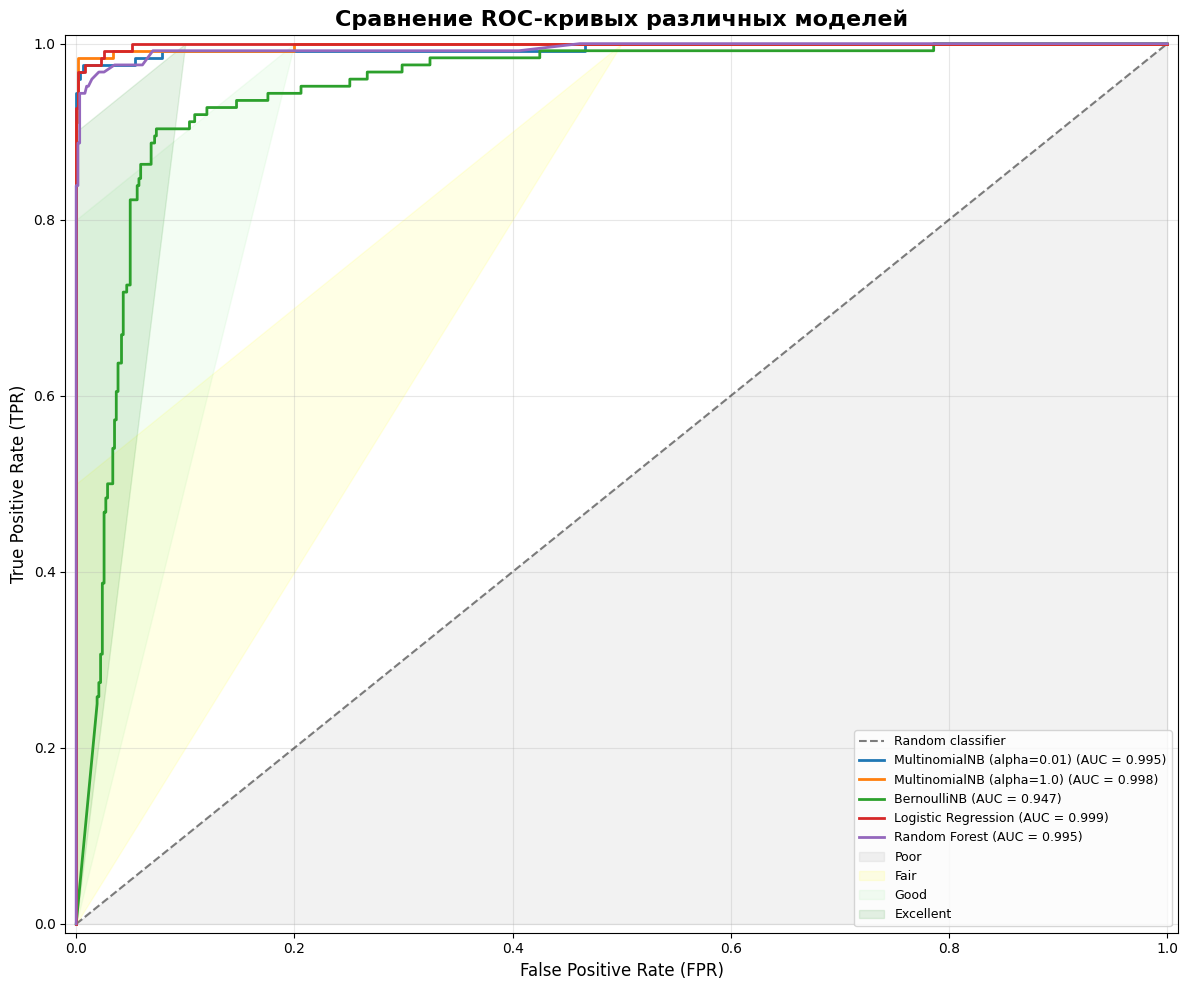

In [134]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Создаем несколько моделей для сравнения
models = {
    'MultinomialNB (alpha=0.01)': MultinomialNB(alpha=0.01),
    'MultinomialNB (alpha=1.0)': MultinomialNB(alpha=1.0),
    'BernoulliNB': BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Обучаем модели и собираем ROC-кривые
plt.figure(figsize=(12, 10))

# Базовая линия (случайный классификатор)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')

# Для каждой модели
for name, model in models.items():
    # Обучение
    model.fit(X_train, y_train)
    
    # Предсказания вероятностей
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
        y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())
    
    # ROC-кривая
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    
    # Рисуем кривую
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

# Настройки графика
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Сравнение ROC-кривых различных моделей', 
          fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)

# Добавляем зоны качества
plt.fill_between([0, 1], [0, 1], alpha=0.1, color='gray', label='Poor')
plt.fill_between([0, 0.5], [0.5, 1], [0, 1], alpha=0.1, color='yellow', label='Fair')
plt.fill_between([0, 0.2], [0.8, 1], [0, 1], alpha=0.1, color='lightgreen', label='Good')
plt.fill_between([0, 0.1], [0.9, 1], [0, 1], alpha=0.1, color='green', label='Excellent')

plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## Задание 5 (3 балла)

Переберите несколько значений alpha с помощью кросс-валидации. Оцените, зависит ли от этого параметра качество классификации.

In [135]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
import numpy as np

# Диапазон alpha
alphas = np.logspace(-3, 1, 10)

# Кросс-валидация
for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print(f"alpha={alpha:.4f}: accuracy={scores.mean():.4f}±{scores.std():.4f}")

# Находим лучшее alpha
best_alpha = alphas[np.argmax([
    cross_val_score(MultinomialNB(alpha=a), X_train, y_train, cv=5, scoring='accuracy').mean()
    for a in alphas
])]

print(f"\nЛучшее alpha: {best_alpha:.4f}")

alpha=0.0010: accuracy=0.9867±0.0058
alpha=0.0028: accuracy=0.9884±0.0038
alpha=0.0077: accuracy=0.9889±0.0037
alpha=0.0215: accuracy=0.9907±0.0017
alpha=0.0599: accuracy=0.9907±0.0033
alpha=0.1668: accuracy=0.9907±0.0033
alpha=0.4642: accuracy=0.9911±0.0024
alpha=1.2915: accuracy=0.9898±0.0023
alpha=3.5938: accuracy=0.9622±0.0177
alpha=10.0000: accuracy=0.8803±0.0080

Лучшее alpha: 0.4642
